In [1]:
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 35) (1409, 35) (5634,) (1409,)


In [2]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

print("Model trained")

Model trained


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8048261178140526
Precision: 0.6523076923076923
Recall: 0.5668449197860963
F1 Score: 0.6065808297567954
ROC-AUC: 0.8421013201064351

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



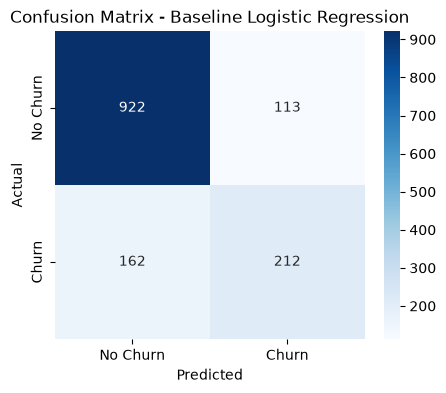

,Feature,Coefficient
25,Contract_Two year,-1.325201
1,tenure,-1.257294
10,InternetService_Fiber optic,1.178197
24,Contract_One year,-0.685712
3,TotalCharges,0.527460
7,PhoneService_Yes,-0.515889
2,MonthlyCharges,-0.460168
28,PaymentMethod_Electronic check,0.384116
26,PaperlessBilling_Yes,0.372724
23,StreamingMovies_Yes,0.371061


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()

# Top coefficients (feature importance for linear model)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.head(10)

In [5]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(baseline_model, '../models/baseline_logistic_regression.pkl')
print("Model saved")

Model saved
